In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

from src.data_loader import load_german, load_bank
from src.preprocessing import preprocess_german, preprocess_bank
from src.model import train_model
from src.explain_shap import shap_analysis

# Explainable AI & Fairness Analysis in Credit Decision Systems

This notebook analyzes machine learning models using:
- SHAP (global explainability)
- LIME (local explanations - external HTML)
- Counterfactual reasoning

Compare two datasets:
- German Credit Dataset
- Bank Marketing Dataset

Goal:
Understand how model decisions differ across datasets and what drives predictions.

In [2]:
df_german = load_german()
X_g, y_g, df_german = preprocess_german(df_german)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=42
)

model_g = train_model(Xg_train, yg_train)

print("German dataset loaded")

German dataset loaded


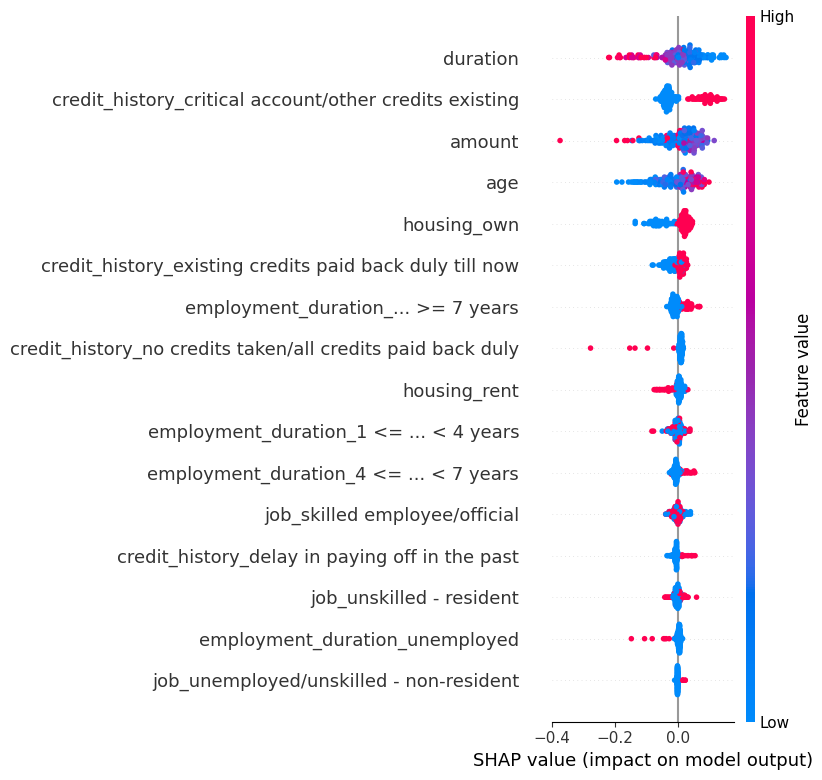

In [3]:
shap_values_g = shap_analysis(model_g, Xg_test)

shap.summary_plot(shap_values_g[:, :, 1], Xg_test)

## German Dataset Insights

- Age plays a significant role in decision-making
- Financial attributes contribute jointly
- No single dominant feature → distributed decision logic

### Interpretation:
The model relies on multiple features rather than a single strong predictor.
This suggests relatively stable decision boundaries.

In [4]:
df_bank = load_bank(sample_size=1500)
X_b, y_b, df_bank = preprocess_bank(df_bank)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

model_b = train_model(Xb_train, yb_train)

print("Bank dataset loaded")

Bank dataset loaded


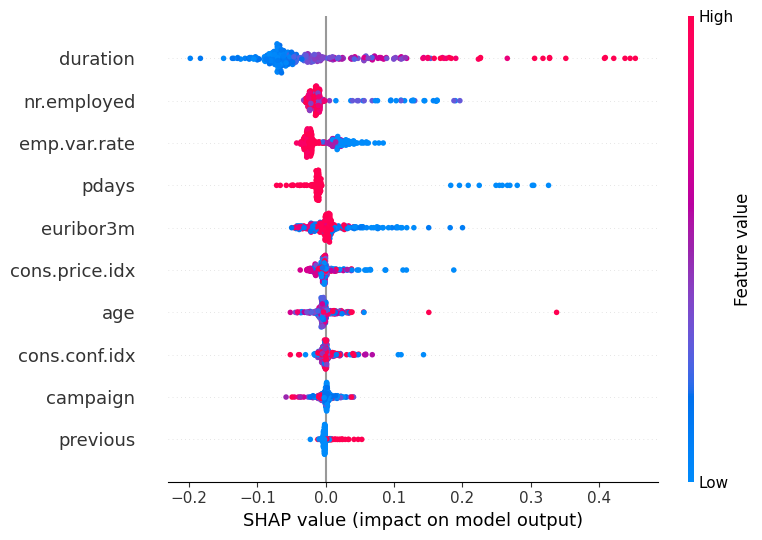

In [5]:
shap_values_b = shap_analysis(model_b, Xb_test)

shap.summary_plot(shap_values_b[:, :, 1], Xb_test)

## Bank Dataset Insights

- Duration is the most influential feature
- Macroeconomic indicators (euribor3m, employment rate) also contribute

### Interpretation:
The model heavily depends on interaction duration, indicating behavioral influence.

In [6]:
results = pd.read_csv("../outputs/comparison_results.csv")
results

,dataset,accuracy,counterfactual_feature,counterfactual_factor
0,bank,0.923333,duration,0.5
1,german,0.680000,age,0.5


## Counterfactual Analysis

Results:

- German → Feature: age
- Bank → Feature: duration

### Interpretation:

- German Dataset:
  Age influences decision outcome → potential demographic sensitivity

- Bank Dataset:
  Duration influences decision → operational/behavioral factor

### Key Insight:
Different datasets produce different decision drivers, showing that explainability is context-dependent.

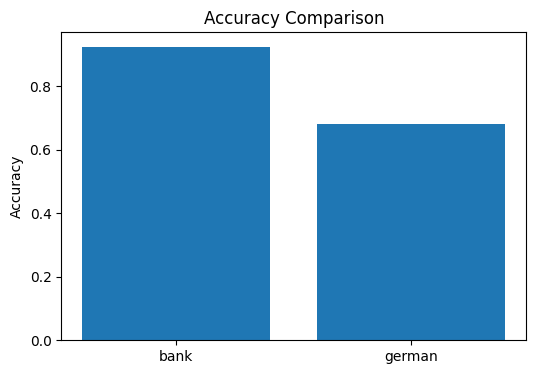

In [7]:
plt.figure(figsize=(6,4))

plt.bar(results['dataset'], results['accuracy'])

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## SHAP vs LIME vs Counterfactual

| Method | Type | Insight |
|------|------|--------|
| SHAP | Global + Local | Feature importance |
| LIME | Local | Instance-level reasoning |
| Counterfactual | Decision Boundary | What changes decision |

### Key Insight:
No single explanation method is sufficient → combined use is required.

## Limitations

- LIME explanations may vary across runs
- SHAP assumes feature independence
- Counterfactuals depend on perturbation strategy

### Important:
Explainability does NOT guarantee correctness or fairness.

## Final Conclusion

This study demonstrates:

- ML models behave differently across datasets
- Decision drivers vary (age vs duration)
- Explainability methods reveal different aspects of model behavior

### Key Takeaway:
Responsible AI requires:
- Transparency
- Multi-method explainability
- Context-aware interpretation

This project moves beyond model accuracy to understanding decision-making processes.